<a href="https://colab.research.google.com/github/alysonbz/NLP/blob/thays/AV2/ap2_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Comparação entre MLP e BERTimbau para Classificação de Sentimentos em Textos de Reviews.**

## **Introdução**

Neste relatório, é comparado o desempenho de dois modelos de aprendizado de máquina em uma tarefa de classificação de sentimento em textos de reviews: uma _MLP (Multilayer Perceptron)_ e o _BERTimbau_, um modelo baseado em _BERT_ pré-treinado para o português. **O objetivo é avaliar a eficácia de um modelo tradicional de aprendizado supervisionado, como a MLP, frente a um modelo baseado em redes neurais profundas e pré-treinamento**.

- **BERTimbau**

O _BERTimbau_ é uma versão adaptada do _BERT (Bidirectional Encoder Representations from Transformers)_ para a língua portuguesa. O _BERT_ é um modelo pré-treinado em grandes quantidades de texto não rotulado e, posteriormente, ajustado para tarefas específicas, como classificação de texto, perguntas e respostas, e tradução. Sua arquitetura, baseada em Transformers, utiliza mecanismos de atenção para processar sequências de palavras, analisando o contexto de forma bidirecional e considerando simultaneamente os termos à esquerda e à direita.

O _BERTimbau_ foi treinado em um grande corpus de textos em português, sendo particularmente útil para tarefas de _Processamento de Linguagem Natural (PLN)_ em português, pois captura melhor as nuances da língua.




## **Observações**

- **O modelo MLP utilizado neste projeto apresenta algumas diferenças em relação à estrutura do modelo apresentado na primeira avaliação. As principais alterações incluem o ajuste da taxa de aprendizado para 1e-5 e a substituição do otimizador de lbfgs para Adam. Essas modificações foram implementadas para padronizar os parâmetros entre ambos os modelos.**

- **Há uma diferença no número de épocas: a MLP foi treinada com 100 épocas, enquanto o BERTimbau utilizou apenas 10, devido ao tempo de processamento do BERTimbau.**

- **Foi mantida uma amostra de 2000 observações do dataset original.**

- **Como sugerido na primeira apresentação, foram retiradas palavras com menos de duas letras e adicionado às stopwords palavras específicas ao contexto.**

## **Metodologia**

> **Por motivos computacionais, foi utilizada uma pequena amostra de 2000 observações do dataset original, sendo 80% dele separado para o treino do modelo. Também foi utilizada a técnica de _Undersampling_ para balancear as classes, que estão divididas em "negativa" e "positiva".**


**MLP:**

- Foi treinado em um conjunto de dados que passou por uma limpeza de texto que incluiu a **remoção de menções, hashtags, URLs, stopwords e a aplicação de lematização**.
- Para a vetorização, foi utilizada a técnica **TF-IDF** (Term Frequency-Inverse Document Frequency), que atribui peso às palavras com base na sua frequência no documento e na coleção de documentos como um todo.
- O modelo foi configurado com duas camadas ocultas, cada uma contendo 50 neurônios, com função de ativação ReLU. O modelo foi treinado utilizando o otimizador _Adam_, com uma taxa de aprendizado inicial de 1e-5 e o número máximo de iterações foi ajustado para 100.

**BERTimbau:**

- Já é pré-treinado e captura relações semânticas e contextuais diretamente dos embeddings gerados por sua arquitetura, eliminando a necessidade de um pré-processamento detalhado e de vetorização manual.
- Neste caso, foi realizada apenas a limpeza de texto.
- A vetorização dos textos foi realizada automaticamente pelos embeddings do modelo pré-treinado.
- Para a classificação das sentenças, utilizou-se o **_BertForSequenceClassification_**, que é uma arquitetura projetada especificamente para tarefas de classificação de texto.

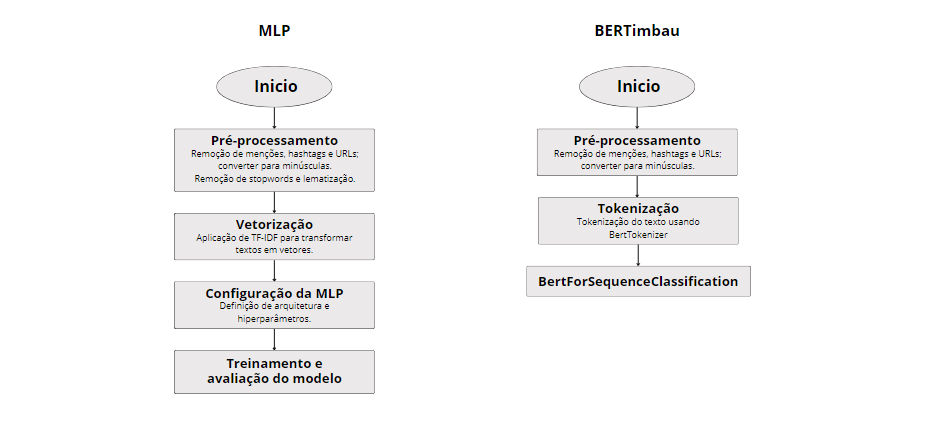

## **Resultados e Discussão**

### **Lendo dados, importando bibliotecas e funções auxiliares**

#### **Packages**

In [ ]:
!pip install evaluate
!pip install transformers datasets
!python -m spacy download pt_core_news_sm
!pip install pyspellchecker

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 61.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from transformers import BertForSequenceClassification, BertTokenizer, Trainer, TrainingArguments, AdamW
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from torch.nn.functional import cross_entropy
from tqdm import tqdm
from sklearn.metrics import log_loss
from torch.utils.data import DataLoader, TensorDataset
import torch
from datasets import load_dataset, DatasetDict, Dataset
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from nltk.tokenize import word_tokenize
from nltk.stem.rslp import RSLPStemmer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import evaluate
import spacy
import nltk
import re


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('rslp')
nltk.download('all')

my_stopwords = ['sobre', 'algum', 'tambem', 'outro', 'poder', 'fazer', 'voce', 'filme', 'sao', 'vez', 'fazer', 'tao']
stopwords_list = stopwords.words('portuguese')

stopwords_list.extend(my_stopwords)

stop_words = set(stopwords_list)

nlp = spacy.load('pt_core_news_sm')
stemmer = RSLPStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!
[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_percept

#### **Dados**

In [ ]:
# df.shape

In [ ]:
dataset = load_dataset("AiresPucrs/sentiment-analysis-pt")

dataset = dataset['train'].to_pandas()

# Amostrar 2000 observações do dataset
dataset = dataset.sample(n=2000, random_state=123).reset_index()

#### **Funções Auxiliares**

##### **Funções para pré-processamento**

In [ ]:
from spellchecker import SpellChecker


spell = SpellChecker(language='pt')


def correct_spelling(text):
  words = text.split()
  words_corrected = []
  for word in words:
      word_corrected = spell.correction(word)
      if word_corrected is not None:
          words_corrected.append(word_corrected)
      else:
          words_corrected.append(word)
  return " ".join(words_corrected)


def clean_text(text):
    text = re.sub(r'@\w+', '', text)  # Remove menções
    text = re.sub(r'#\w+', '', text)  # Remove hashtags
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'\d+', '', text)  # Remove numeros
    text = text.lower()  # Converte para minúsculas
    # text = correct_spelling(text)  # corrigir ortografia
    return text


def remove_stopwords(text, stop_words):
    return ' '.join([word for word in word_tokenize(text) if word not in stop_words and len(word) > 2])  # remover stopwords


def lemmatize(text):
    return ' '.join([token.lemma_ for token in nlp(text)])  # lematizar

##### **Funções para vetorização**

In [ ]:
def calculate_word_frequencies(docs):
    """
    Calcula o vocabulário e a frequência de palavras para cada documento.

    Args:
        docs (list): Lista de documentos (strings).

    Retorna:
        set: Vocabulário (palavras únicas em todos os documentos).
        list: Lista de dicionários com a frequência de palavras para cada documento.
    """
    vocabulary = set()
    word_frequencies = []

    for doc in docs:
        words = doc.split()
        vocabulary.update(words)
        freq = {}
        for word in words:
            freq[word] = freq.get(word, 0) + 1
        word_frequencies.append(freq)

    return vocabulary, word_frequencies


def calculate_idf(docs, vocabulary):

    """
    Calcula a frequência inversa de documentos (IDF) para cada palavra no vocabulário.

    Args:
        docs (list): Lista de documentos (strings).
        vocabulary (set): Conjunto de palavras únicas em todos os documentos.

    Retorna:
        dict: Dicionário contendo o IDF para cada palavra no vocabulário.
    """

    num_docs = len(docs)
    idf = {}

    for word in vocabulary:
        num_docs_with_word = sum(1 for doc in docs if word in doc)
        idf[word] = np.log(num_docs / (1 + num_docs_with_word))

    return idf


def compute_tfidf_vector(frequencies, idf, vocabulary):

    """
    Calcula o vetor TF-IDF para um único documento.

    Args:
        frequencies (dict): Frequência de palavras para o documento.
        idf (dict): Valores de IDF para cada palavra no vocabulário.
        vocabulary (list): Lista de palavras únicas em todos os documentos.

    Retorna:
        list: Vetor TF-IDF para o documento.
    """

    return [frequencies.get(word, 0) * idf.get(word, 0) for word in vocabulary]


def vectorize_tfidf(docs):

    """
    Vetoriza os documentos usando o método TF-IDF.

    Args:
        docs (list): Lista de documentos (strings).

    Retorna:
        list: Matriz de vetores TF-IDF para todos os documentos.
        list: Vocabulário utilizado para o cálculo do TF-IDF.
    """

    vocabulary, word_frequencies = calculate_word_frequencies(docs)
    idf = calculate_idf(docs, vocabulary)
    vocabulary = list(vocabulary)

    tfidf_matrix = [
        compute_tfidf_vector(frequencies, idf, vocabulary) for frequencies in word_frequencies
    ]

    return tfidf_matrix, vocabulary

##### **Funções para treinamento do modelo MLP**

In [ ]:
# Função para treinar o MLP e coletar métricas
def train_MLP(clf, X_train, y_train, X_val, y_val, epochs):
    # Listas para armazenar as perdas e acurácias de treino e validação
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    # Treinamento manual, uma época por vez
    for epoch in range(epochs):
        clf.fit(X_train, y_train)  # Treina o modelo por 1 época

        # Predição no conjunto de treino e validação
        y_pred_train = clf.predict(X_train)
        y_pred_val = clf.predict(X_val)

        # Calculando a perda (loss) e a acurácia para treino e validação
        train_losses.append(clf.loss_)
        train_accuracies.append(accuracy_score(y_train, y_pred_train))
        test_losses.append(log_loss(y_val, clf.predict_proba(X_val)))  # Usando log_loss para validação
        test_accuracies.append(accuracy_score(y_val, y_pred_val))

    return train_losses, train_accuracies, test_losses, test_accuracies


##### **Funções para treinamento do modelo BERTimbau**

In [ ]:
def tokenize_data(texts, tokenizer, max_length=128):
    tokens = tokenizer(texts.tolist(),
                       padding=True,        # Preencher os textos curtos
                       truncation=True,     # Truncar textos muito longos
                       max_length=max_length,
                       return_tensors="pt")  # Retornar tensores para PyTorch

    return tokens


# Função de treinamento
def train_BERT(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for batch in tqdm(dataloader):
        input_ids = batch[0].to(device) # Changed to numerical index
        attention_mask = batch[1].to(device) # Changed to numerical index
        labels = batch[2].to(device) # Changed to numerical index

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predictions = torch.argmax(outputs.logits, dim=-1)
        total_correct += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    accuracy = total_correct / total_samples
    return total_loss / len(dataloader), accuracy


# Função de avaliação
def evaluate_BERT(model, dataloader, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch[0].to(device) # Changed to numerical index
            attention_mask = batch[1].to(device) # Changed to numerical index
            labels = batch[2].to(device) # Changed to numerical index
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels) #Added labels to the model call during evaluation to enable loss calculation
            loss = outputs.loss

            total_loss += loss.item()
            predictions = torch.argmax(outputs.logits, dim=-1)
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    accuracy = total_correct / total_samples
    return total_loss / len(dataloader), accuracy, all_labels, all_predictions

##### **Funções para visualização do resultado**

In [ ]:
def plotar_epocas(epochs, train_losses, val_losses, train_accuracies, val_accuracies, titulo):
  plt.figure(figsize=(12, 4))

  plt.suptitle(titulo, fontsize=14)

  # Subplot para perda
  plt.subplot(1, 2, 1)
  plt.plot(range(1, len(train_losses) + 1), train_losses, label='Treino', marker='o')
  plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validação', marker='o')
  plt.xlabel('Época')
  plt.ylabel('Loss')
  plt.title('Loss')
  plt.legend()

  # Subplot para acurácia
  plt.subplot(1, 2, 2)
  plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Treino', marker='o')
  plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validação', marker='o')
  plt.xlabel('Época')
  plt.ylabel('Acurácia')
  plt.title('Acurácia')
  plt.legend()

  plt.tight_layout()
  plt.show()


def plotar_matriz_confusao(y_test, y_pred, titulo):
  plt.figure(figsize=(4, 2))
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
  plt.title(titulo)
  plt.xlabel('Predição')
  plt.ylabel('Valor Real')
  plt.show()

### **Balanceamento com Undersampling**

In [ ]:
class_counts = dataset['label'].value_counts()
print(class_counts)

# Define a classe majoritária e minoritária
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

# Seleciona amostras da classe majoritária igual ao número da classe minoritária
df_majority = dataset[dataset['label'] == majority_class]
df_minority = dataset[dataset['label'] == minority_class]

df_majority_undersampled = df_majority.sample(n=len(df_minority), random_state=42)
dataset = pd.concat([df_majority_undersampled, df_minority], axis=0)

class_counts_undersampled = dataset['label'].value_counts()
print(class_counts_undersampled)


label
0    1050
1     950
Name: count, dtype: int64
label
0    950
1    950
Name: count, dtype: int64


### **Classificação com MLP**

#### **Limpeza de texto**

> A padronização do texto foi aplicada diretamente na variável, pois é utilizado a mesma padronização no modelo BERT.

In [ ]:
dataset['text'] = dataset['text'].apply(clean_text)

In [ ]:
dataset['text_processed'] = dataset['text'].apply(remove_stopwords, args=(stopwords_list,))
dataset['text_processed'] = dataset['text_processed'].apply(lemmatize)

#### **Vetorização**

In [ ]:
docs = dataset['text_processed'].tolist()
matriz_tfidf_preproc, vocabulario_tfidf_preproc = vectorize_tfidf(docs)

#### **Dividindo os conjuntos**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(matriz_tfidf_preproc,
                                                    dataset['label'],
                                                    test_size=0.2,
                                                    random_state=42)

#### **Classificação**

In [ ]:
# Definir o modelo MLP
clf = MLPClassifier(max_iter=1,  # Treinamos 1 época de cada vez
                    activation='relu',
                    hidden_layer_sizes=(50, 50),
                    learning_rate_init=1e-5,
                    solver='adam',
                    warm_start=True,  # Permite continuar treinando a partir do estado atual
                    verbose=True)



train_losses_mlp, train_accuracies_mlp, test_losses_mlp, test_accuracies_mlp  = train_MLP(clf, X_train, y_train, X_test, y_test, epochs=100)

Iteration 1, loss = 0.70335543
Iteration 1, loss = 0.69816031
Iteration 1, loss = 0.69312891
Iteration 1, loss = 0.68809234
Iteration 1, loss = 0.68325426
Iteration 1, loss = 0.67854772
Iteration 1, loss = 0.67395769
Iteration 1, loss = 0.66938626
Iteration 1, loss = 0.66480488
Iteration 1, loss = 0.66044502
Iteration 1, loss = 0.65611026
Iteration 1, loss = 0.65183145
Iteration 1, loss = 0.64759012
Iteration 1, loss = 0.64328846
Iteration 1, loss = 0.63914505
Iteration 1, loss = 0.63501857
Iteration 1, loss = 0.63087594
Iteration 1, loss = 0.62669601
Iteration 1, loss = 0.62261517
Iteration 1, loss = 0.61868454
Iteration 1, loss = 0.61466974
Iteration 1, loss = 0.61071460
Iteration 1, loss = 0.60680188
Iteration 1, loss = 0.60282724
Iteration 1, loss = 0.59895877
Iteration 1, loss = 0.59508890
Iteration 1, loss = 0.59121872
Iteration 1, loss = 0.58741459
Iteration 1, loss = 0.58357122
Iteration 1, loss = 0.57981021
Iteration 1, loss = 0.57594890
Iteration 1, loss = 0.57218653
Iteratio

#### **Report do modelo**

In [ ]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.77      0.72       189
           1       0.73      0.63      0.68       191

    accuracy                           0.70       380
   macro avg       0.70      0.70      0.70       380
weighted avg       0.70      0.70      0.70       380



- O modelo alcançou uma taxa de acerto de 70% na classificação dos textos.
- A precisão para a classe positiva foi de 73%, mas o recall de 63% revela que o modelo não conseguiu identificar todos os exemplos que eram, de fato, positivos.
- Na classe negativa, o recall foi superior, atingindo 77%, enquanto a precisão ficou em 67%, o que indica que o modelo tem mais facilidade em detectar textos negativos do que positivos.
- O F1-score, que combina precisão e recall, também é ligeiramente superior para a classe 0 (negativos) em comparação à classe 1 (positivos).

In [ ]:
y_test_mlp = y_test # preservar para plot de erro de previsão
y_pred_mlp = y_pred

### **Classificação com BERTimbau**

#### **Dividindo os conjuntos**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(dataset['text'],
                                                    dataset['label'],
                                                    test_size=0.2,
                                                    random_state=42)

#### **Limpeza de texto**

In [ ]:
X_train = X_train.apply(clean_text)
X_test = X_test.apply(clean_text)

#### **Tokenização**

In [ ]:
# Carregar o tokenizador do BERTimbau
tokenizer = BertTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')

# # Tokenizar os dados de treino e teste
X_train = tokenize_data(X_train, tokenizer)
X_test = tokenize_data(X_test, tokenizer)

#### **Convertendo os labels para tensores PyTorch**

In [ ]:
# Converter os labels para tensores PyTorch
train_labels = torch.tensor(y_train.values)
test_labels = torch.tensor(y_test.values)

In [ ]:
# Criar datasets
train_dataset = TensorDataset(X_train['input_ids'], X_train['attention_mask'], train_labels)
test_dataset = TensorDataset(X_test['input_ids'], X_test['attention_mask'], test_labels)

# Criar DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

#### **_BertForSequenceClassification_**

In [ ]:
# Carregar o modelo BERTimbau para classificação
model = BertForSequenceClassification.from_pretrained('neuralmind/bert-base-portuguese-cased', num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Definir otimizador
optimizer = AdamW(model.parameters(), lr=1e-5)

In [ ]:
# Inicializando listas para perdas e acurácias
train_losses_BERT = []
train_accuracies_BERT = []
val_losses_BERT = []
val_accuracies_BERT = []

epochs = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")

    # Treinamento
    train_loss, train_accuracy = train_BERT(model, train_loader, optimizer, device)
    train_losses_BERT.append(train_loss)
    train_accuracies_BERT.append(train_accuracy)

    # Avaliação
    val_loss, val_accuracy, val_labels, val_predictions = evaluate_BERT(model, test_loader, device)
    val_losses_BERT.append(val_loss)
    val_accuracies_BERT.append(val_accuracy)

    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

Epoch 1/10


100%|██████████| 24/24 [00:02<00:00,  9.42it/s]


Train Loss: 0.6459, Train Accuracy: 0.6243
Val Loss: 0.4820, Val Accuracy: 0.8026
Epoch 2/10


100%|██████████| 24/24 [00:02<00:00,  8.80it/s]


Train Loss: 0.4144, Train Accuracy: 0.8184
Val Loss: 0.3947, Val Accuracy: 0.8263
Epoch 3/10


...

Train Loss: 0.0400, Train Accuracy: 0.9895
Val Loss: 0.6096, Val Accuracy: 0.8500
Epoch 9/10


100%|██████████| 24/24 [00:02<00:00,  8.52it/s]


Train Loss: 0.0214, Train Accuracy: 0.9934
Val Loss: 0.6502, Val Accuracy: 0.8474
Epoch 10/10


100%|██████████| 24/24 [00:02<00:00,  8.50it/s]

Train Loss: 0.0199, Train Accuracy: 0.9967
Val Loss: 0.6937, Val Accuracy: 0.8500


#### **Report do modelo**

In [ ]:
print(classification_report(val_labels, val_predictions))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       189
           1       0.86      0.84      0.85       191

    accuracy                           0.85       380
   macro avg       0.85      0.85      0.85       380
weighted avg       0.85      0.85      0.85       380



- O modelo classifica corretamente 85% de todos os textos, independentemente da classe.

- A precisão é de 0.84 para a classe 0 e 0.86 para a classe 1. Isso significa que, em média, 85% dos textos classificados como positivos ou negativos estavam corretos.

- O F1-score é de 0.85 para ambas as classes, refletindo um bom equilíbrio entre precisão e recall, indicando que o modelo classifica sem favorecer excessivamente uma classe em detrimento da outra.

### **Comparação de desempenho**

> Ambos os modelos foram treinados utilizando o mesmo otimizador e mesma taxa de aprendizado, sendo a MLP treinada 90 épocas a mais que o modelo BERTimbau e aplicado técnicas de lematização e TD-IDF.

#### **Interpretação dos Resultados**

##### **Desempenho Geral**

- **O BERTimbau apresenta um desempenho significativamente melhor do que a MLP** na tarefa de classificação, como indicado pela acurácia, que é 85% para o BERTimbau, comparado a 70% para a MLP.

##### **Capacidade de identificação**

- **Sentimentos Negativos (Classe 0):** O BERTimbau não só obteve uma precisão superior, mas também um recall melhor, o que significa que ele consegue identificar mais textos negativos corretamente, reduzindo a quantidade de falsos negativos. Isso é crucial em aplicações onde a identificação de sentimentos negativos é sensível, como em análises de opinião ou feedback de clientes.

- **Sentimentos Positivos (Classe 1):** Embora a MLP tenha apresentado uma boa performance, o BERTimbau superou a MLP tanto em precisão quanto em recall. Isso mostra que o BERTimbau tem uma compreensão mais refinada dos textos, capturando os sentimentos positivos com mais eficácia, o que pode ser especialmente relevante em contextos de marketing ou engajamento.



#### **Acurácia e Loss por época**

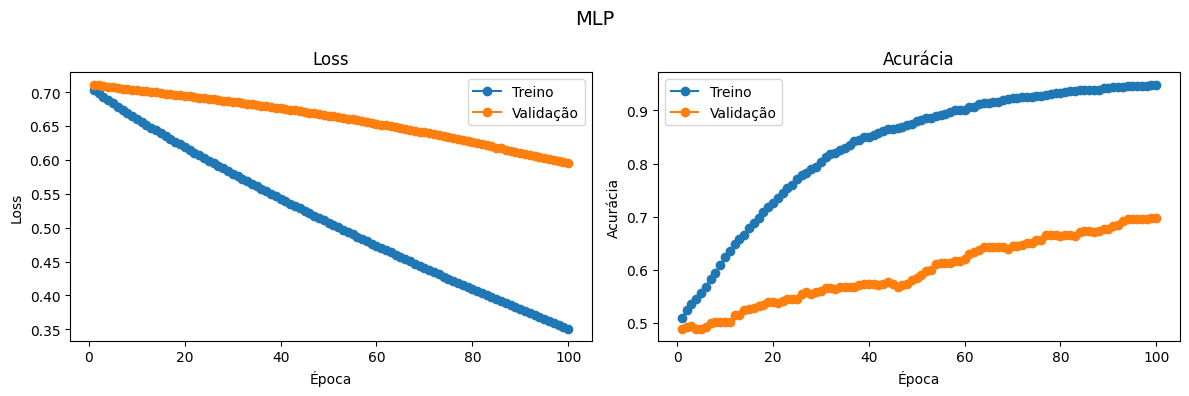

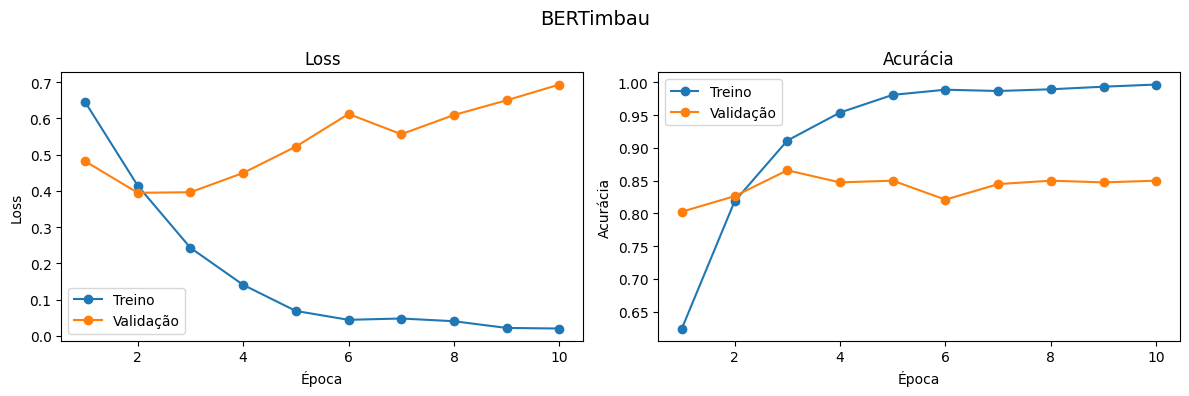

In [ ]:
plotar_epocas(epochs, train_losses_mlp, test_losses_mlp, train_accuracies_mlp, test_accuracies_mlp, titulo='MLP')
plotar_epocas(epochs, train_losses_BERT, val_losses_BERT, train_accuracies_BERT, val_accuracies_BERT, titulo='BERTimbau')

#### **Erros de previsão**

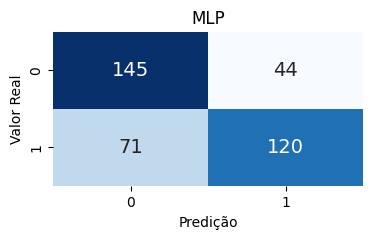

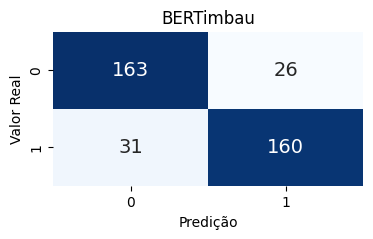

In [ ]:
plotar_matriz_confusao(y_test_mlp, y_pred_mlp, titulo='MLP')
plotar_matriz_confusao(val_labels, val_predictions, titulo='BERTimbau')

## **Considerações Finais**

A comparação entre a MLP e o BERTimbau destaca a superioridade dos modelos baseados em Transformer em tarefas de classificação de sentimentos. O BERTimbau não apenas alcançou melhores métricas, mas também demonstrou uma capacidade mais robusta de entender e classificar sentimentos expressos em textos. Para aplicações que exigem precisão e sensibilidade, o BERTimbau se mostra a escolha mais adequada.